In [4]:

filename = "Grieg_1"
piano = "Shigeru_Kawai_CG"

def set_filenames():
    global filename
    global piano  
    global originalMIDI
    global originalTXT
    global originalPNG
    global originalAUDIO
    global originalVIDEO
    global generatedMIDI
    global generatedTXT
    global generatedPNG
    global generatedAUDIO
    global generatedVIDEO
    originalMIDI = filename + ".mid"
    originalTXT = filename + ".txt"
    originalPNG = filename + ".png"
    originalAUDIO = filename + ".mp3"
    originalVIDEO = filename + ".mp4"
    generatedMIDI = filename + "_out.mid"
    generatedTXT = filename + "_out.txt"
    generatedPNG = filename + "_out.png"
    generatedAUDIO = filename + "_out.wav"
    generatedVIDEO = filename + "_out.mp4"
set_filenames()
print("original MIDI filename:", originalMIDI)
print("original TXT filename:", originalTXT)
print("original PNG filename:", originalPNG)
print("original AUDIO filename:", originalAUDIO)
print("original VIDEO filename:", originalVIDEO)
print("generated MIDI filename:", generatedMIDI)
print("generated TXT filename:", generatedTXT)
print("generated PNG filename:", generatedPNG)
print("generated VIDEO filename:", generatedAUDIO)
from IPython.display import Audio
from IPython.display import Video

original MIDI filename: Grieg_1.mid
original TXT filename: Grieg_1.txt
original PNG filename: Grieg_1.png
original AUDIO filename: Grieg_1.mp3
original VIDEO filename: Grieg_1.mp4
generated MIDI filename: Grieg_1_out.mid
generated TXT filename: Grieg_1_out.txt
generated PNG filename: Grieg_1_out.png
generated VIDEO filename: Grieg_1_out.wav


In [5]:

Video(originalVIDEO, embed=True)

In [6]:

print("original Audio file: " + originalAUDIO)
Audio(originalAUDIO)

original Audio file: Grieg_1.mp3


ValueError: rate must be specified when data is a numpy array or list of audio samples.

In [79]:
import sys
!{sys.executable} -u example.py --audio_path={originalAUDIO} --output_midi_path={generatedMIDI}


Checkpoint path: /Users/user/piano_transcription_inference_data/note_F1=0.9677_pedal_F1=0.9186.pth
Using cpu for inference.
Using CPU.
Segment 0 / 3
Segment 1 / 3
Segment 2 / 3
Segment 3 / 3
Write out to Grieg_1_out.mid
Transcribe time: 6.799 s


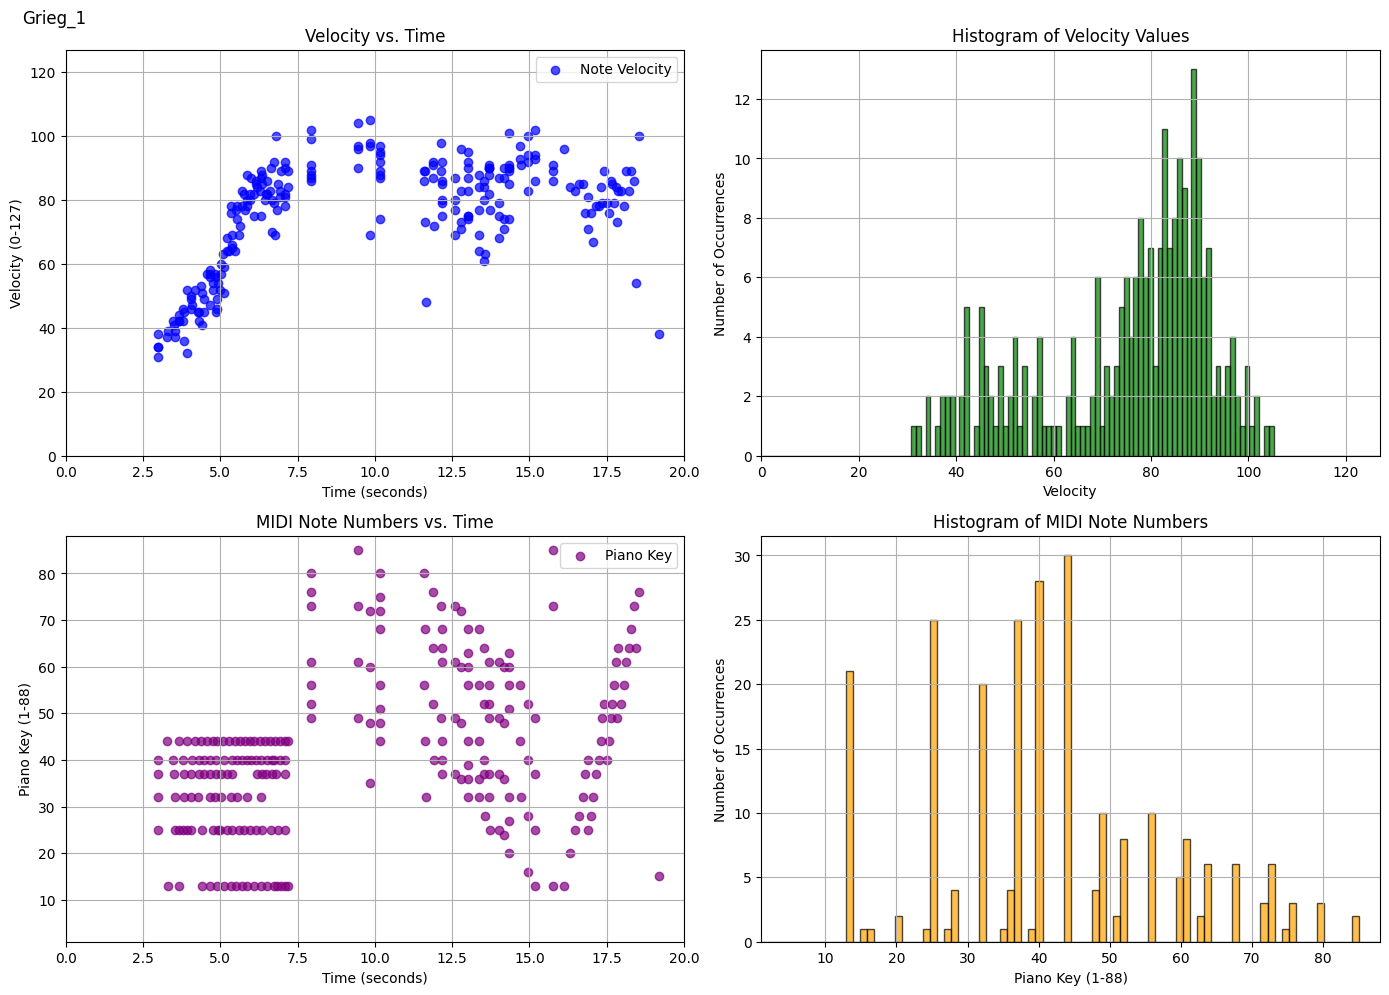

PLOTS saved to: Grieg_1_out.png
MIDI events saved to: Grieg_1_out.txt


In [80]:
def midi_to_text_and_plot(midi_path, text_path, plot_path, title_text):
    """
    Decodes a MIDI file, writes its events into a text file, and plots:
    1) Velocity vs. Time (ignoring velocity 0) with Y-axis from 0 to 127
    2) Histogram of Velocity Values with 128 bins and X-axis from 0 to 127
    3) MIDI Note Numbers vs. Time mapped to piano keys (1-88)
    4) Histogram of MIDI Note Numbers (mapped to 1-88) with 88 bins
    Args:
        midi_path (str): Path to the input MIDI file.
        text_path (str): Path to save the output text file.
        plot_path (str): Path to save the generated plot as a PNG file.
        title_text (str): Text to be displayed in the upper left corner of the plot.
    """
    import mido
    import matplotlib.pyplot as plt

    midi_file = mido.MidiFile(midi_path)
    ticks_per_beat = midi_file.ticks_per_beat
    tempo = 500000  # Default 120 BPM tempo (500,000 microseconds per beat)

    # Store extracted data
    velocity_values = []
    velocity_times = []
    note_numbers = []
    note_times = []

    with open(text_path, 'w') as text_file:
        text_file.write(f"MIDI File: {midi_path}\n")
        text_file.write(f"Ticks per Beat: {ticks_per_beat}\n\n")

        absolute_ticks = 0  # Tracks cumulative time in ticks

        for i, track in enumerate(midi_file.tracks):
            text_file.write(f"Track {i}: {track.name}\n")
            text_file.write("-" * 40 + "\n")

            for msg in track:
                absolute_ticks += msg.time  # Convert relative to absolute time

                # Tempo Change Handling (Optional)
                if msg.type == 'set_tempo':
                    tempo = msg.tempo  # Set new tempo

                # Convert MIDI ticks to seconds
                seconds = mido.tick2second(absolute_ticks, ticks_per_beat, tempo)

                # Note-On Event (Velocity > 0)
                if msg.type == 'note_on' and msg.velocity > 0:
                    velocity_values.append(msg.velocity)  # Store velocity
                    velocity_times.append(seconds)         # Store time for velocity
                    note_numbers.append(msg.note)            # Store MIDI note number
                    note_times.append(seconds)               # Store time for note

                    text_file.write(f"Time {seconds:.3f} sec | NOTE_ON  | "
                                    f"Note: {msg.note:3d} | Velocity: {msg.velocity:3d}\n")

                # Note-Off Event
                elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
                    text_file.write(f"Time {seconds:.3f} sec | NOTE_OFF | "
                                    f"Note: {msg.note:3d} | Velocity: 0\n")

            text_file.write("\n")

    # Map MIDI note numbers to piano keys: MIDI 21 -> 1, MIDI 108 -> 88.
    mapped_note_numbers = [n - 20 for n in note_numbers]

    # Generate Plots as Subplots if there is any velocity data
    if velocity_values:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # Top Left: Velocity vs. Time (set Y-axis from 0 to 127)
        axes[0, 0].scatter(velocity_times, velocity_values, color='b', alpha=0.7, label="Note Velocity")
        axes[0, 0].set_xlabel("Time (seconds)")
        axes[0, 0].set_ylabel("Velocity (0-127)")
        axes[0, 0].set_title("Velocity vs. Time")
        axes[0, 0].legend()
        axes[0, 0].grid()
        axes[0, 0].set_ylim(0, 127)
        axes[0, 0].set_xlim(left=0)
        axes[0, 0].text(-0.07, 1.1, title_text, transform=axes[0, 0].transAxes, fontsize=12, verticalalignment='top')

        # Bottom Left: MIDI Note Numbers vs. Time (mapped to 1-88)
        axes[1, 0].scatter(note_times, mapped_note_numbers, color='purple', alpha=0.7, label="Piano Key")
        axes[1, 0].set_xlabel("Time (seconds)")
        axes[1, 0].set_ylabel("Piano Key (1-88)")
        axes[1, 0].set_title("MIDI Note Numbers vs. Time")
        axes[1, 0].legend()
        axes[1, 0].grid()
        axes[1, 0].set_xlim(left=0)
        axes[1, 0].set_ylim(1, 88)

        # Top Right: Histogram of Velocity Values (set X-axis from 0 to 127)
        axes[0, 1].hist(velocity_values, bins=128, range=(0, 127), color='g', alpha=0.7, edgecolor='black')
        axes[0, 1].set_xlabel("Velocity")
        axes[0, 1].set_ylabel("Number of Occurrences")
        axes[0, 1].set_title("Histogram of Velocity Values")
        axes[0, 1].grid()
        axes[0, 1].set_xlim(0, 127)

        # Bottom Right: Histogram of MIDI Note Numbers (mapped to 1-88)
        axes[1, 1].hist(mapped_note_numbers, bins=88, range=(1, 88), color='orange', alpha=0.7, edgecolor='black')
        axes[1, 1].set_xlabel("Piano Key (1-88)")
        axes[1, 1].set_ylabel("Number of Occurrences")
        axes[1, 1].set_title("Histogram of MIDI Note Numbers")
        axes[1, 1].grid()
        axes[1, 1].set_xlim(1, 88)

        plt.tight_layout()
        plt.savefig(plot_path)  # Save plot as PNG file
        plt.show()

    print(f"PLOTS saved to: {plot_path}")
    print(f"MIDI events saved to: {text_path}")
midi_to_text_and_plot(generatedMIDI, generatedTXT, generatedPNG, filename )

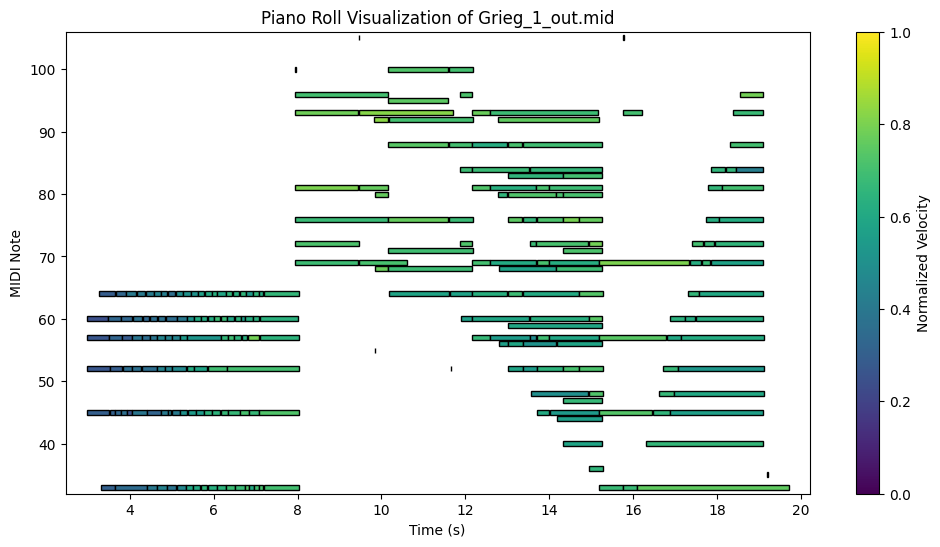

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pretty_midi

def visualize_piano_roll_from_midi():
    """
    Load a MIDI file ("input.mid"), extract note events, and visualize them as a piano roll.
    Each note is drawn as a rectangle from onset to offset time at the pitch corresponding to the MIDI note.
    The rectangle color intensity indicates the normalized note velocity.
    """
    # Load the MIDI file
    midi_data = pretty_midi.PrettyMIDI(generatedMIDI)
    note_events = []

    # Iterate through all instruments and extract note events
    for instrument in midi_data.instruments:
        # Optionally, skip drum instruments if desired:
        # if instrument.is_drum:
        #     continue
        for note in instrument.notes:
            start = note.start
            end = note.end
            pitch = note.pitch
            # Normalize velocity (MIDI velocities are 0-127)
            velocity = note.velocity / 127.0  
            note_events.append([start, end, pitch, velocity])
    
    # Convert the list to a numpy array and ensure it's 2D
    note_events = np.atleast_2d(np.array(note_events))
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.cm.viridis  # colormap for velocity

    # Draw each note as a rectangle
    for note in note_events:
        onset, offset, midi_note, velocity = note
        duration = offset - onset
        color = cmap(velocity)
        rect = patches.Rectangle((onset, midi_note - 0.4), duration, 0.8,
                                 linewidth=1, edgecolor='black', facecolor=color)
        ax.add_patch(rect)
        
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("MIDI Note")
    ax.set_title("Piano Roll Visualization of " + generatedMIDI)
    
    # Set x-axis limits based on note onsets and offsets
    time_min = np.min(note_events[:, 0]) - 0.5
    time_max = np.max(note_events[:, 1]) + 0.5
    ax.set_xlim(time_min, time_max)
    
    # Set y-axis limits based on MIDI note numbers
    midi_min = np.min(note_events[:, 2]) - 1
    midi_max = np.max(note_events[:, 2]) + 1
    ax.set_ylim(midi_min, midi_max)
    
    # Add a colorbar to indicate velocity
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("Normalized Velocity")
    
    plt.show()

# Call the function to visualize the piano roll from "input.mid"
visualize_piano_roll_from_midi()


In [46]:
import subprocess

# Render the MIDI file to a WAV file using FluidSynth with the specified soundfont.
fluidsynth_path = r"SOUNDFONTS/bin/fluidsynth.exe"
soundfont_path = r"SOUNDFONTS/KAWAI_MP11SE_SK_Concert_Grand.sf2"

fluidsynth_cmd = (
    f'"{fluidsynth_path}" -ni "{soundfont_path}" "{generatedMIDI}" '
    f'-F "{generatedAUDIO}" -r 44100 -g 1'
)

subprocess.run(fluidsynth_cmd, shell=True, check=True)
print(f"WAV file '{generatedAUDIO}' generated successfully!")
Audio(generatedAUDIO)



In [47]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # Allow Pygame to run in headless mode
import mido
#import pygame
import pygame
import moviepy.editor as mpy
#from moviepy.config import change_settings
from pygame.locals import *

import moviepy.config as mpy_config
import imageio_ffmpeg
# Use the ffmpeg binary provided by imageio_ffmpeg.
mpy_config.change_settings({"FFMPEG_BINARY": imageio_ffmpeg.get_ffmpeg_exe()})

# The following line has been removed because it forces MoviePy to use an ffmpeg binary that does not exist.
# change_settings({"FFMPEG_BINARY": "/opt/homebrew/bin/ffmpeg"})

# Constants for visualization
WHITE_KEY_WIDTH = 20
WHITE_KEY_HEIGHT = 120
BLACK_KEY_WIDTH = int(WHITE_KEY_WIDTH * 0.65)  # Black keys are 65% the width of white keys
BLACK_KEY_HEIGHT = int(WHITE_KEY_HEIGHT * 0.7)  # Black keys are 70% the height of white keys
FPS = 30
VIDEO_OUTPUT = "keyboard_visualization_with_audio.mp4"

# Map MIDI notes to key positions
# (Each tuple represents a key: the letter indicates whether the key is white ("W") or black ("B")
#  and the number is its relative position in the octave.)
KEYS = [
    ('W', 0), ('B', 1), ('W', 2), ('W', 3), ('B', 4),
    ('W', 5), ('B', 6), ('W', 7), ('W', 8), ('B', 9), ('W', 10), ('B', 11)
]
NUM_WHITE_KEYS = 52
NUM_BLACK_KEYS = 36
NUM_KEYS = 88
START_NOTE = 21  # MIDI number for A0

def note_to_position(note):
    """Converts a MIDI note number to its position on the keyboard."""
    key_offset = note - START_NOTE
    if key_offset < 0 or key_offset >= NUM_KEYS:
        return None, None  # Ignore notes outside the keyboard range

    octave = key_offset // 12
    key_index = key_offset % 12
    key_type, _ = KEYS[key_index]

    if key_type == 'W':
        white_index = sum(1 for k, _ in KEYS[:key_index] if k == 'W') + octave * 7
        return white_index, 'W'
    elif key_type == 'B':
        black_index = sum(1 for k, _ in KEYS[:key_index] if k == 'B') + octave * 5
        return black_index, 'B'

    return None, None

def parse_midi(midi_file):
    """Parses MIDI events and returns note on/off events with timestamps."""
    midi = mido.MidiFile(midi_file)
    events = []
    time = 0
    for msg in midi:
        time += msg.time
        # Only process note_on and note_off events.
        if msg.type in ['note_on', 'note_off']:
            # For note_on, use the velocity; for note_off, use 0.
            events.append((time, msg.note, msg.velocity if msg.type == 'note_on' else 0))
        # Any pedal events (control_change with control 64) are ignored.
    return events

def visualize_keyboard(events, output_path, audio_file):
    """Generates a video visualizing the keyboard based on MIDI events and includes audio."""
    # Initialize pygame in headless mode
    pygame.init()
    screen_width = WHITE_KEY_WIDTH * NUM_WHITE_KEYS
    screen_height = WHITE_KEY_HEIGHT + 20  # Add extra space for border
    screen = pygame.Surface((screen_width, screen_height))

    # Prepare the list of frames.
    frames = []
    white_keys_pressed = [False] * NUM_WHITE_KEYS
    black_keys_pressed = [False] * NUM_BLACK_KEYS
    event_index = 0

    def draw_keyboard():
        """Draws the keyboard (with any keys highlighted that are currently 'pressed')."""
        # Draw a border (frame) around the keyboard.
        pygame.draw.rect(screen, (50, 50, 50),
                         (0, 0, WHITE_KEY_WIDTH * NUM_WHITE_KEYS, WHITE_KEY_HEIGHT + 10))

        # Draw white keys.
        for i in range(NUM_WHITE_KEYS):
            color = (255, 255, 255) if not white_keys_pressed[i] else (200, 0, 0)
            pygame.draw.rect(screen, color, (i * WHITE_KEY_WIDTH, 10, WHITE_KEY_WIDTH - 1, WHITE_KEY_HEIGHT))
            pygame.draw.rect(screen, (0, 0, 0), (i * WHITE_KEY_WIDTH, 10, WHITE_KEY_WIDTH - 1, WHITE_KEY_HEIGHT), 1)

        # Draw black keys.
        black_key_offsets = [0.6, 2.6, 3.6, 5.6, 6.6]  # Offsets for black keys within an octave.
        for octave in range(7):  # For 7 octaves from A0 to B7 (roughly).
            for i, offset in enumerate(black_key_offsets):
                black_index = octave * 5 + i
                if 0 <= black_index < NUM_BLACK_KEYS:
                    x_pos = (octave * 7 + offset) * WHITE_KEY_WIDTH
                    color = (0, 0, 0) if not black_keys_pressed[black_index] else (200, 0, 0)
                    pygame.draw.rect(screen, color, (x_pos, 10, BLACK_KEY_WIDTH, BLACK_KEY_HEIGHT))

        # Manually draw the last black key (B7) if needed.
        last_black_key_x = (49 * WHITE_KEY_WIDTH) + (0.6 * WHITE_KEY_WIDTH)
        color = (0, 0, 0) if not black_keys_pressed[-1] else (200, 0, 0)
        pygame.draw.rect(screen, color, (last_black_key_x, 10, BLACK_KEY_WIDTH, BLACK_KEY_HEIGHT))

    max_time = events[-1][0] if events else 0
    # Process frames at the designated FPS.
    for frame_time in range(int(max_time * FPS)):
        current_time = frame_time / FPS
        # Process all events up to the current time.
        while event_index < len(events) and events[event_index][0] <= current_time:
            _, note, velocity = events[event_index]
            key_index, key_type = note_to_position(note)
            if key_index is not None:
                if key_type == 'W':
                    white_keys_pressed[key_index] = (velocity > 0)
                elif key_type == 'B':
                    black_keys_pressed[key_index] = (velocity > 0)
            event_index += 1

        draw_keyboard()
        # Convert the Pygame surface into an image frame (RGB).
        frames.append(pygame.surfarray.array3d(screen).transpose((1, 0, 2)))

    # Create the video using MoviePy.
    def make_frame(t):
        frame_index = min(int(t * FPS), len(frames) - 1)
        return frames[frame_index]

    print("Loading audio clip...")
    audio = mpy.AudioFileClip(audio_file)
    
    print("Building video clip...")
    clip = mpy.VideoClip(make_frame, duration=max_time)
    clip = clip.set_audio(audio)

    print("Writing final video...")
    clip.write_videofile(
        output_path,
        fps=FPS,
        codec="libx264",
        audio_codec="aac",
        ffmpeg_params=["-pix_fmt", "yuv420p"]
    )
    print(f"Video saved to: {output_path}")

# ----------------- EXECUTION BLOCK ----------------- #
# Adjust these file paths as needed
midi_file = generatedMIDI
audio_file = generatedAUDIO
output_video = generatedVIDEO

# Check if files exist
if not os.path.exists(midi_file):
    print(f"MIDI file not found: {midi_file}")
elif not os.path.exists(audio_file):
    print(f"Audio file not found: {audio_file}")
else:
    print("Parsing MIDI file...")
    midi_events = parse_midi(midi_file)
    print("Generating video...")
    visualize_keyboard(midi_events, output_video, audio_file)


Parsing MIDI file...
Generating video...
Loading audio clip...
Building video clip...
Writing final video...
Moviepy - Building video Grieg_2_out.mp4.
MoviePy - Writing audio in Grieg_2_outTEMP_MPY_wvf_snd.mp4


MoviePy - Done.
Moviepy - Writing video Grieg_2_out.mp4



Moviepy - Done !
Moviepy - video ready Grieg_2_out.mp4
Video saved to: Grieg_2_out.mp4


In [48]:
from IPython.display import Video
Video(generatedVIDEO, embed=True)